# Phân loại chuyển động mắt bằng GMM-HMM phân cấp — chạy toàn bộ 87 file

Pipeline: K-Means SSE + Elbow chọn K → GMM-HMM tầng 1 (x, y) → GMM-HMM tầng 2 (v) cho từng section → gộp bằng K-Means 3 cụm trên log10(vận tốc trung bình).

**Cấu hình cố định :** `n_mix=1`, `covariance_type="spherical"`, `min_seg_len=10`, `standardize=False`, đặc trưng tầng 1 = (x, y). Các thông số EM / K-Means (`n_iter=25`, `tol=1e-4`, `n_restarts=2`, K-Means SSE 30 vòng × 3 restart), seed tầng 2 (`seed+100`) .
Ground Truth chỉ dùng để đánh giá sau khi dự đoán.

In [ ]:
import logging, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn.hmm import GMMHMM
from joblib import Parallel, delayed
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

# ====== CẤU HÌNH CỐ ĐỊNH ======
CFG = {
    "seed": 42,
    "k_max": 9,
    "kmeans_max_iter": 30,
    "kmeans_restarts": 3,
    "l1_features": ("x", "y"),
    "l2_features": ("v",),
    "n_mix": 2,
    "covariance_type": "spherical",
    "n_iter": 25,
    "tol": 1e-4,
    "n_restarts": 2,
    "min_seg_len": 10,
    "standardize": False,
}

# Thư mục chứa 87 file [x, y, v, ground_truth]; sửa lại nếu cần
CANDIDATES = [Path("../dataset/testdataset"), Path("dataset/testdataset"), Path("testdataset")]
DATA_DIR = next(p for p in CANDIDATES if p.is_dir())
RESULTS_DIR = DATA_DIR.parent / "results"   # chứa <tên>_results.csv với cột "manually results"
FILES = sorted(DATA_DIR.glob("*.txt"))
print(f"Dữ liệu: {DATA_DIR.resolve()}  |  {len(FILES)} file")

Dữ liệu: D:\Thanh\TLHT\HK 9\HTTM\workspace\eyemovement_ec\dataset\testdataset  |  87 file


## 1. Hàm lõi của pipeline

In [2]:
def load_data(path):
    matrix = np.atleast_2d(np.loadtxt(path))
    if matrix.shape[1] < 3:
        raise ValueError(f"{path} cần ít nhất 3 cột [x, y, v].")
    features = pd.DataFrame(matrix[:, :3], columns=("x", "y", "v"))
    ground_truth = (
        matrix[:, 3].astype(int) if matrix.shape[1] >= 4 else None
    )
    return features, ground_truth


def kmeans_sse(data, n_clusters, max_iter, restarts, rng):
    """Tính SSE bằng K-Means tự cài đặt, không dùng sklearn KMeans."""
    best_sse = np.inf
    for _ in range(restarts):
        centers = data[rng.choice(len(data), n_clusters, replace=False)].copy()
        for _ in range(max_iter):
            distances = ((data[:, None, :] - centers[None, :, :]) ** 2).sum(2)
            labels = distances.argmin(1)
            new_centers = np.array([
                data[labels == cluster].mean(0)
                if np.any(labels == cluster) else centers[cluster]
                for cluster in range(n_clusters)
            ])
            if np.allclose(new_centers, centers):
                break
            centers = new_centers
        sse = float(((data - centers[labels]) ** 2).sum())
        best_sse = min(best_sse, sse)
    return best_sse


def choose_k(data, cfg, requested_k=None):
    if requested_k is not None:
        if requested_k < 1 or requested_k > len(data):
            raise ValueError("K phải nằm trong khoảng [1, số điểm].")
        return requested_k

    max_k = min(cfg["k_max"], len(data))
    ks = np.arange(1, max_k + 1)
    if len(ks) < 3:
        return int(ks[-1])

    rng = np.random.default_rng(cfg["seed"])
    sse = np.array([
        kmeans_sse(
            data,
            int(k),
            cfg["kmeans_max_iter"],
            cfg["kmeans_restarts"],
            rng,
        )
        for k in ks
    ])
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (sse - sse.min()) / (sse.max() - sse.min() + 1e-12)
    distance = np.abs((y[-1] - y[0]) * x - (x[-1] - x[0]) * y
                      + x[-1] * y[0] - y[-1] * x[0])
    return int(ks[int(distance.argmax())])


def fit_gmmhmm(data, n_states, cfg, seed):
    """Thử nhiều restart; nếu n_mix=2 thất bại thì fallback về n_mix=1."""
    mix_values = list(dict.fromkeys((cfg["n_mix"], 1)))
    for n_mix in mix_values:
        best_model = None
        best_score = -np.inf
        for restart in range(cfg["n_restarts"]):
            try:
                model = GMMHMM(
                    n_components=n_states,
                    n_mix=n_mix,
                    covariance_type=cfg["covariance_type"],
                    n_iter=cfg["n_iter"],
                    tol=cfg["tol"],
                    min_covar=1e-3,
                    random_state=seed + restart,
                    verbose=False,
                )
                model.fit(data)
                score = float(model.score(data))
                if np.isfinite(score) and score > best_score:
                    best_model, best_score = model, score
            except (ValueError, np.linalg.LinAlgError, FloatingPointError):
                continue
        if best_model is not None:
            return best_model
    return None


def scale(data, enabled):
    return StandardScaler().fit_transform(data) if enabled else data


def velocity_mapping(stats, cfg):
    """Tạo mapping state cục bộ -> lớp vận tốc từ toàn bộ section."""
    velocities = np.log10(np.maximum(np.asarray(stats)[:, 2], 0) + 1e-6)
    if len(velocities) >= 3:
        model = KMeans(
            n_clusters=3,
            n_init=10,
            random_state=cfg["seed"],
        ).fit(velocities.reshape(-1, 1))
        order = np.argsort(model.cluster_centers_.ravel())
        cluster_to_class = {
            int(cluster): rank for rank, cluster in enumerate(order)
        }
        return {
            (int(section), int(state)): cluster_to_class[int(cluster)]
            for (section, state, _), cluster in zip(stats, model.labels_)
        }, model.cluster_centers_.ravel()[order]

    # Không đủ state để chạy K-Means 3 cụm: xếp trực tiếp theo vận tốc.
    order = np.argsort(velocities)
    return {
        (int(stats[index][0]), int(stats[index][1])): min(rank, 2)
        for rank, index in enumerate(order)
    }, velocities[order]


def classify(data, cfg, requested_k=None):
    xy = data[["x", "y"]].to_numpy()
    k = choose_k(xy, cfg, requested_k)
    layer1_input = scale(data[list(cfg["l1_features"])].to_numpy(),
                         cfg["standardize"])
    layer1 = fit_gmmhmm(layer1_input, k, cfg, cfg["seed"])
    if layer1 is None:
        raise RuntimeError("Không fit được GMM-HMM tầng 1 sau mọi restart.")

    _, segment_states = layer1.decode(layer1_input, algorithm="viterbi")
    velocity = data["v"].to_numpy()
    local_states = np.full(len(data), -1, dtype=int)
    stats = []
    tiny_sections = []

    for section in np.unique(segment_states):
        indices = np.flatnonzero(segment_states == section)
        if len(indices) < cfg["min_seg_len"]:
            tiny_sections.append(indices)
            continue
        layer2_input = scale(
            data.iloc[indices][list(cfg["l2_features"])].to_numpy(),
            cfg["standardize"],
        )
        layer2 = fit_gmmhmm(
            layer2_input,
            3,
            cfg,
            cfg["seed"] + 100,
        )
        if layer2 is None:
            tiny_sections.append(indices)
            continue
        _, states = layer2.decode(layer2_input, algorithm="viterbi")
        local_states[indices] = states
        for state in np.unique(states):
            state_velocity = velocity[indices[states == state]]
            stats.append((section, state, float(state_velocity.mean())))

    if not stats:
        raise RuntimeError("Không có section đủ dữ liệu để phân loại tầng 2.")

    mapping, centers = velocity_mapping(stats, cfg)
    prediction = np.full(len(data), -1, dtype=int)
    for index in np.flatnonzero(local_states >= 0):
        key = (int(segment_states[index]), int(local_states[index]))
        if key not in mapping:
            raise RuntimeError(f"Thiếu mapping cho state {key}.")
        prediction[index] = mapping[key]

    # Section ngắn/fail dùng tâm velocity global, không dùng Ground Truth.
    for indices in tiny_sections:
        distances = np.abs(
            np.log10(np.maximum(velocity[indices], 0) + 1e-6)[:, None]
            - centers[None, :]
        )
        prediction[indices] = distances.argmin(1).clip(max=2)

    if np.any(prediction < 0):
        raise RuntimeError("Một số điểm chưa được gán nhãn dự đoán.")
    return prediction, k, len(tiny_sections), segment_states, local_states

## 2. Chạy toàn bộ file và đánh giá

In [3]:
CLASSES = ("Fixation", "Smooth Pursuit", "Saccade")


def load_labels(path, fallback):
    """Nhãn từ results/<tên>_results.csv (như lúc tuning); thiếu thì dùng cột 4 của file txt."""
    csv = RESULTS_DIR / f"{path.stem}_results.csv"
    if csv.is_file():
        c = pd.read_csv(csv); c.columns = [x.strip().lower() for x in c.columns]
        return c["manually results"].values.astype(int)
    return fallback


def evaluate_file(path, cfg=CFG):
    data, gt = load_data(path)
    gt = load_labels(path, gt)
    assert len(gt) == len(data), f"{path.name}: {len(data)} điểm nhưng {len(gt)} nhãn"
    pred, k, tiny, _, _ = classify(data, cfg)
    p, r, f, _ = precision_recall_fscore_support(gt, pred, labels=[0, 1, 2], zero_division=0)
    row = {"file": path.name, "n_points": len(data), "K": k, "fallback_sections": tiny,
           "accuracy": accuracy_score(gt, pred),
           "precision": p.mean(), "recall": r.mean(), "f1": f.mean()}
    for i, c in enumerate(CLASSES):
        row[f"P_{c}"], row[f"R_{c}"], row[f"F1_{c}"] = p[i], r[i], f[i]
    return row


def safe_eval(path):
    try:
        return evaluate_file(path)
    except Exception as e:  # file lỗi vẫn được ghi lại, không làm dừng cả lượt chạy
        return {"file": path.name, "error": str(e)}


t0 = time.time()
rows = Parallel(n_jobs=-1)(delayed(safe_eval)(p) for p in FILES)
df = pd.DataFrame(rows)
print(f"Xong {len(df)} file trong {time.time() - t0:.0f}s")
if "error" in df:
    print("File lỗi:", df.loc[df["error"].notna(), ["file", "error"]].to_string(index=False))
    df = df[df["error"].isna()].drop(columns="error")
df.to_csv("results_per_file.csv", index=False)
df.head()

Xong 87 file trong 7s


,file,n_points,K,fallback_sections,accuracy,precision,recall,f1,P_Fixation,R_Fixation,F1_Fixation,P_Smooth Pursuit,R_Smooth Pursuit,F1_Smooth Pursuit,P_Saccade,R_Saccade,F1_Saccade
0,tester01_1.txt,371,4,0,0.938005,0.931591,0.864607,0.894670,0.945017,0.992780,0.968310,0.886792,0.734375,0.803419,0.962963,0.866667,0.912281
1,tester01_2.txt,375,4,0,0.832000,0.837778,0.678030,0.732337,0.846667,0.988327,0.912029,0.666667,0.430380,0.523077,1.000000,0.615385,0.761905
2,tester01_3.txt,402,4,0,0.970149,0.963735,0.962148,0.961616,0.995968,0.972441,0.984064,0.895238,0.989474,0.940000,1.000000,0.924528,0.960784
3,tester01_4.txt,370,4,0,0.959459,0.937231,0.953807,0.944597,0.977974,0.982301,0.980132,0.950000,0.904762,0.926829,0.883721,0.974359,0.926829
4,tester01_5.txt,371,4,0,0.975741,0.963059,0.949625,0.956101,0.982818,0.993056,0.987910,0.943396,0.892857,0.917431,0.962963,0.962963,0.962963


## 3. Tổng hợp (trung bình ± độ lệch chuẩn trên các file)

In [4]:
PAPER = {"Accuracy": 94.39, "Precision": 95.31, "Recall": 94.98, "F1": 94.92,
         "Fixation": 96.99, "Smooth Pursuit": 88.93, "Saccade": 90.77}  # Bảng 1-4, Xie et al. 2025

ours = {"Accuracy": df.accuracy.mean() * 100, "Precision": df.precision.mean() * 100,
        "Recall": df.recall.mean() * 100, "F1": df.f1.mean() * 100,
        **{c: df[f"F1_{c}"].mean() * 100 for c in CLASSES}}
std = {"Accuracy": df.accuracy.std(ddof=0) * 100, "Precision": df.precision.std(ddof=0) * 100,
       "Recall": df.recall.std(ddof=0) * 100, "F1": df.f1.std(ddof=0) * 100,
       **{c: df[f"F1_{c}"].std(ddof=0) * 100 for c in CLASSES}}

summary = pd.DataFrame({"Thực nghiệm (mean)": ours, "Thực nghiệm (std)": std, "Paper": PAPER}).round(2)
summary["Chênh lệch"] = (summary["Thực nghiệm (mean)"] - summary["Paper"]).round(2)
summary.to_csv("summary.csv")
print(f"{len(df)} file | K trung bình = {df.K.mean():.2f} | file có section fallback: {(df.fallback_sections > 0).sum()}")
summary

87 file | K trung bình = 3.55 | file có section fallback: 2


,Thực nghiệm (mean),Thực nghiệm (std),Paper,Chênh lệch
Accuracy,87.07,7.82,94.39,-7.32
Precision,85.06,7.73,95.31,-10.25
Recall,84.22,10.64,94.98,-10.76
F1,82.96,10.64,94.92,-11.96
Fixation,92.60,5.22,96.99,-4.39
Smooth Pursuit,74.02,17.11,88.93,-14.91
Saccade,82.24,14.22,90.77,-8.53


## 4. Biểu đồ so sánh với paper

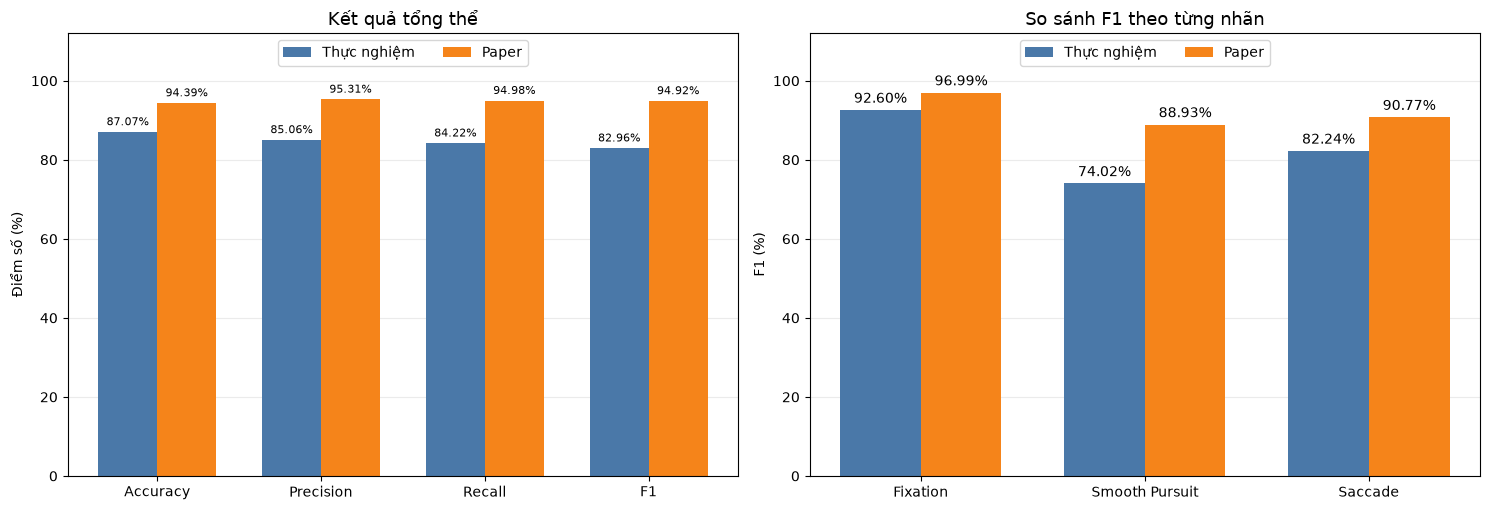

In [5]:
LABEL = "Thực nghiệm"
BLUE, ORANGE = "#4a78a8", "#f5841a"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

def grouped(ax, names, a, b, title, ylabel, fs):
    x = np.arange(len(names)); w = 0.36
    b1 = ax.bar(x - w / 2, a, w, color=BLUE, label=LABEL)
    b2 = ax.bar(x + w / 2, b, w, color=ORANGE, label="Paper")
    for bars in (b1, b2):
        for r in bars:
            ax.text(r.get_x() + r.get_width() / 2, r.get_height() + 1, f"{r.get_height():.2f}%",
                    ha="center", va="bottom", fontsize=fs)
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_ylim(0, 112); ax.set_yticks(range(0, 101, 20))
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=13)
    ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
    ax.legend(loc="upper center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 1.0))

m = ["Accuracy", "Precision", "Recall", "F1"]
grouped(axes[0], m, [ours[k] for k in m], [PAPER[k] for k in m], "Kết quả tổng thể", "Điểm số (%)", 8)
grouped(axes[1], list(CLASSES), [ours[c] for c in CLASSES], [PAPER[c] for c in CLASSES],
        "So sánh F1 theo từng nhãn", "F1 (%)", 10)
plt.tight_layout()
plt.savefig("comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Xem kết quả phân loại trên một file

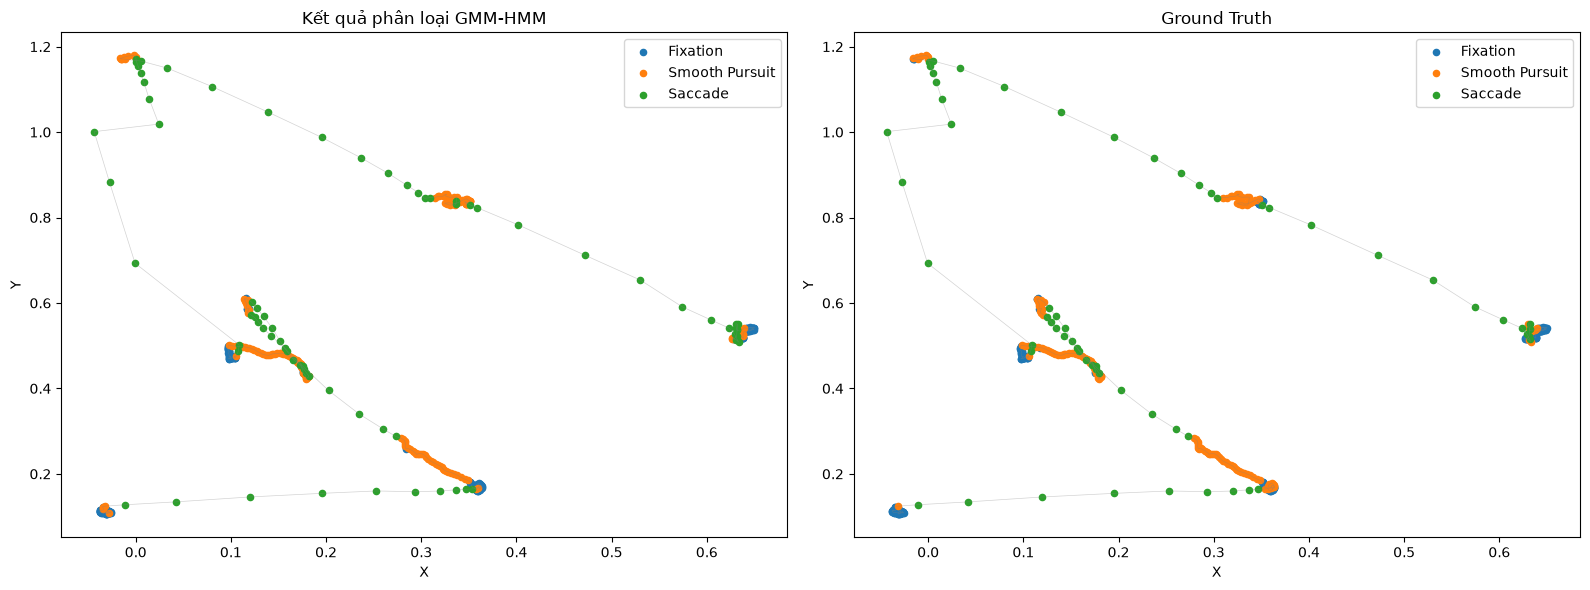

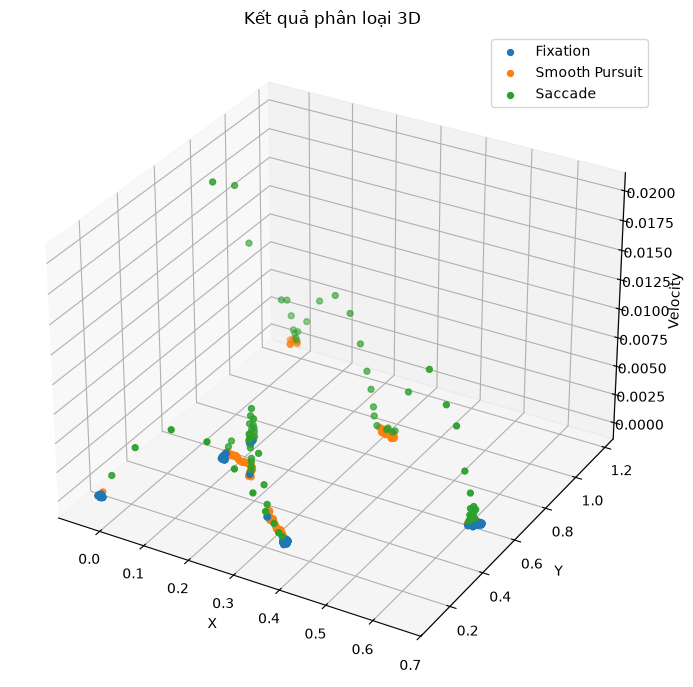

In [6]:
def plot_classification(data, prediction, ground_truth=None):
    """Hiển thị nhãn dự đoán và Ground Truth nếu file có cột thứ tư."""
    plots = [("Kết quả phân loại GMM-HMM", prediction)]
    if ground_truth is not None:
        plots.append(("Ground Truth", ground_truth))

    fig, axes = plt.subplots(
        1, len(plots), figsize=(8 * len(plots), 6), squeeze=False
    )
    for axis, (title, labels) in zip(axes[0], plots):
        labels = np.asarray(labels)
        for label in range(3):
            mask = labels == label
            if np.any(mask):
                axis.scatter(
                    data.loc[mask, "x"],
                    data.loc[mask, "y"],
                    s=20,
                    label=("Fixation", "Smooth Pursuit", "Saccade")[label],
                )
        axis.plot(data["x"], data["y"], color="gray", alpha=0.35, linewidth=0.5)
        axis.set_xlabel("X")
        axis.set_ylabel("Y")
        axis.set_title(title)
        axis.legend()
    fig.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(10, 7))
    axis = fig.add_subplot(111, projection="3d")
    for label in range(3):
        mask = np.asarray(prediction) == label
        if np.any(mask):
            axis.scatter(
                data.loc[mask, "x"],
                data.loc[mask, "y"],
                data.loc[mask, "v"],
                s=18,
                label=("Fixation", "Smooth Pursuit", "Saccade")[label],
            )
    axis.set_xlabel("X")
    axis.set_ylabel("Y")
    axis.set_zlabel("Velocity")
    axis.set_title("Kết quả phân loại 3D")
    axis.legend()
    plt.tight_layout()
    plt.show()


demo = DATA_DIR / "tester11_1.txt"
d, g = load_data(demo)
pred, *_ = classify(d, CFG)
plot_classification(d, pred, g)